In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import concurrent.futures
import scipy.spatial.distance


gleap_target = md.load("../../2_md-preparation/gleap.target.gro")
atom_indices_ligand = gleap_target.topology.select("resid 33")
atom_indices_rna     = gleap_target.topology.select("resid  0 to 32")
atom_index_ligand_min = min(atom_indices_ligand)

pickle_dir = "./pickle-cache/interactions_pi-stacking"


def calculate_interactions(xtc):
    aroma_atomnames = {
        "TRP": ["CG","CD1","NE1","CE2","CD2","CE2","CD2","CE3","CZ3","CH2","CZ2"],
        "PHE": ["CG","CD1","CE1","CZ","CE2","CD2"],
        "TYR": ["CG","CD1","CE1","CZ","CE2","CD2"],
        "HIS": ["CG","ND1","CE1","NE2","CD2"],
        "HIP": ["CG","ND1","CE1","NE2","CD2"],
        "HID": ["CG","ND1","CE1","NE2","CD2"],
        "HIE": ["CG","ND1","CE1","NE2","CD2"],
        "PRF": ["N1","C2","N3","C4","C5","C6","N9","C7","C8"],
        "A":   ["N1","C2","N3","C4","C5","C6","C4","C5","N7","C8","N9"],
        "C":   ["N1","C2","N3","C4","C5","C6"],
        "G":   ["N1","C2","N3","C4","C5","C6","C4","C5","N7","C8","N9"],
        "U":   ["N1","C2","N3","C4","C5","C6"],
    }

    residue_indices_ligand = []
    residue_indices_rna   = []
    for residue in gleap_target.topology.residues:
        if residue.name in aroma_atomnames:
            atom_index = [atom.index for atom in residue.atoms if atom.name in aroma_atomnames[residue.name]]
            if not atom_index:
                continue
            if residue.index == 33:
                residue_indices_ligand.append((residue.index, atom_index))
            elif 0 <= residue.index <= 32:
                residue_indices_rna.append((residue.index, atom_index))

    coms_ligand = np.zeros((xtc.n_frames, len(residue_indices_ligand), 3))
    coms_rna     = np.zeros((xtc.n_frames, len(residue_indices_rna), 3))

    for i, (_, idx) in enumerate(residue_indices_ligand):
        coms_ligand[:, i] = md.compute_center_of_mass(xtc.atom_slice(idx))
    for i, (_, idx) in enumerate(residue_indices_rna):
        coms_rna    [:, i] = md.compute_center_of_mass(xtc.atom_slice(idx))

    interactions = np.zeros((len(atom_indices_ligand),len(atom_indices_rna),xtc.n_frames))
    for timestep in range(xtc.n_frames):
        distance_matrix = scipy.spatial.distance.cdist(coms_ligand[timestep], coms_rna[timestep])
        for atom_index_ligand, atom_index_rna in zip(*np.where((0 < distance_matrix) & (distance_matrix < 0.5))):
            index_ligand = residue_indices_ligand[atom_index_ligand][1][0] - atom_index_ligand_min
            index_rna     = residue_indices_rna[atom_index_rna][1][0]
            interactions[index_ligand, index_rna, timestep] += 1

    return interactions


if True:
    def worker(trial):
        print(trial, "start")
        if trial == "cmd":
            interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 801))
            xtc = md.load(f"../../6_cmd-1/cmd.skip10.whole.target.xtc", top=gleap_target)[2001::10]
            interactions = calculate_interactions(xtc)
            nonzero_indices = interactions.nonzero()
            nonzero_values  = interactions[nonzero_indices]
            pickle.dump([nonzero_indices, nonzero_values], open(f"{pickle_dir}/cmd_interactions.pickle", "wb"))

        else:
            interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 120))
            if trial == 5:
                trial = 11
            xtc = md.load(f"../../pacs2/trial{trial+1:03}/prd.target.trjcat-all.pbc.skip10.xtc", top=gleap_target)[::10]
            coms_ligand             = md.compute_center_of_mass(xtc.atom_slice(atom_indices_ligand))
            coms_rna = md.compute_center_of_mass(xtc.atom_slice(atom_indices_rna))
            com_distances = np.linalg.norm(coms_rna-coms_ligand, axis=1)
            com_distances_binned = (com_distances*10).astype(int)

            _interactions = calculate_interactions(xtc)
            for timestep, com_distance_binned in enumerate(com_distances_binned):
                interactions[:, :, com_distance_binned] += _interactions[:, :, timestep]

            nonzero_indices = interactions.nonzero()
            nonzero_values  = interactions[nonzero_indices]
            pickle.dump([nonzero_indices, nonzero_values], open(f"{pickle_dir}/pacs_interactions_{trial}.pickle", "wb"))
            pickle.dump(np.bincount(com_distances_binned, minlength=120), open(f"{pickle_dir}/pacs_com_distances_bincount_{trial}.pickle", "wb"))
        print(trial, "completed")

    if not os.path.exists(pickle_dir):
        os.mkdir(pickle_dir)
    trials = ["cmd"]
    trials.extend(range(10))
    # for _ in concurrent.futures.ProcessPoolExecutor(max_workers=12).map(worker, trials):
    #     pass
    for i in trials:
        print('dealing ' + str(i))
        worker(i)


cmd_interactions = np.zeros((len(atom_indices_ligand), len(atom_indices_rna), 801))
with open(f"{pickle_dir}/cmd_interactions.pickle", "rb") as f:
    obj = pickle.load(f)
    nonzero_indices   = obj[0]
    nonzero_values  = obj[1]
# _, _, nonzero_indices, nonzero_values = pickle.load(open(f"{pickle_dir}/cmd_interactions.pickle", "rb"))
print(nonzero_indices)
cmd_interactions[nonzero_indices] = nonzero_values

pacs_interactions = np.zeros((10, len(atom_indices_ligand), len(atom_indices_rna), 120))
pacs_com_distances_bincount = np.zeros((10, 120))
for trial in range(len(pacs_interactions)):
    with open(f"{pickle_dir}/pacs_interactions_{trial}.pickle", "rb") as f:
        obj = pickle.load(f)
        nonzero_indices   = obj[0]
        nonzero_values  = obj[1]
    # _, _, nonzero_indices, nonzero_values = pickle.load(open(f"{pickle_dir}/pacs_interactions_{trial}.pickle", "rb"))
    pacs_interactions[trial][nonzero_indices] = nonzero_values
    pacs_com_distances_bincount[trial] = pickle.load(open(f"{pickle_dir}/pacs_com_distances_bincount_{trial}.pickle", "rb"))

pacs_interactions /= pacs_com_distances_bincount[:, np.newaxis, np.newaxis, :]
del pacs_com_distances_bincount

dealing cmd
cmd start
cmd completed
dealing 0
0 start
0 completed
dealing 1
1 start
1 completed
dealing 2
2 start


KeyboardInterrupt: 

In [2]:
gleap_target = md.load("../../2_md-preparation/gleap.target.gro")
for residue in gleap_target.topology.residues:
    print(residue.index, residue.name, str(residue))

0 C5 C51
1 U U2
2 G G3
3 G G4
4 G G5
5 U U6
6 C C7
7 G G8
8 C C9
9 A A10
10 G G11
11 U U12
12 A A13
13 A A14
14 C C15
15 C C16
16 C C17
17 C C18
18 A A19
19 G G20
20 U U21
21 U U22
22 A A23
23 A A24
24 C C25
25 A A26
26 A A27
27 A A28
28 A A29
29 C C30
30 A A31
31 A A32
32 G3 G333
33 pq0 pq034


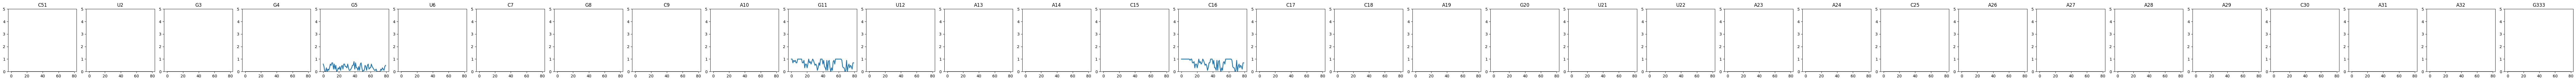

In [15]:
YMAX = 5

fig, ax = plt.subplots(1,33)
fig.set_size_inches(92, 3)

for residue_index_rna in range(0, 33):
    atom_indices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")
    atom_index_rna_residue_min = min(atom_indices_rna_residue)
    atom_index_rna_residue_max = max(atom_indices_rna_residue)
    ax[residue_index_rna].plot(cmd_interactions[:, atom_index_rna_residue_min:atom_index_rna_residue_max+1, :-1].sum(axis=(0, 1)).reshape(-1, 10).mean(axis=1), linewidth=2)

    ax[residue_index_rna].set_title(gleap_target.topology.residue(residue_index_rna))
    ax[residue_index_rna].set_ylim(0, YMAX)

fig.tight_layout()
fig.savefig("./figures/pi_stacking1.png", dpi=300, bbox_inches="tight")

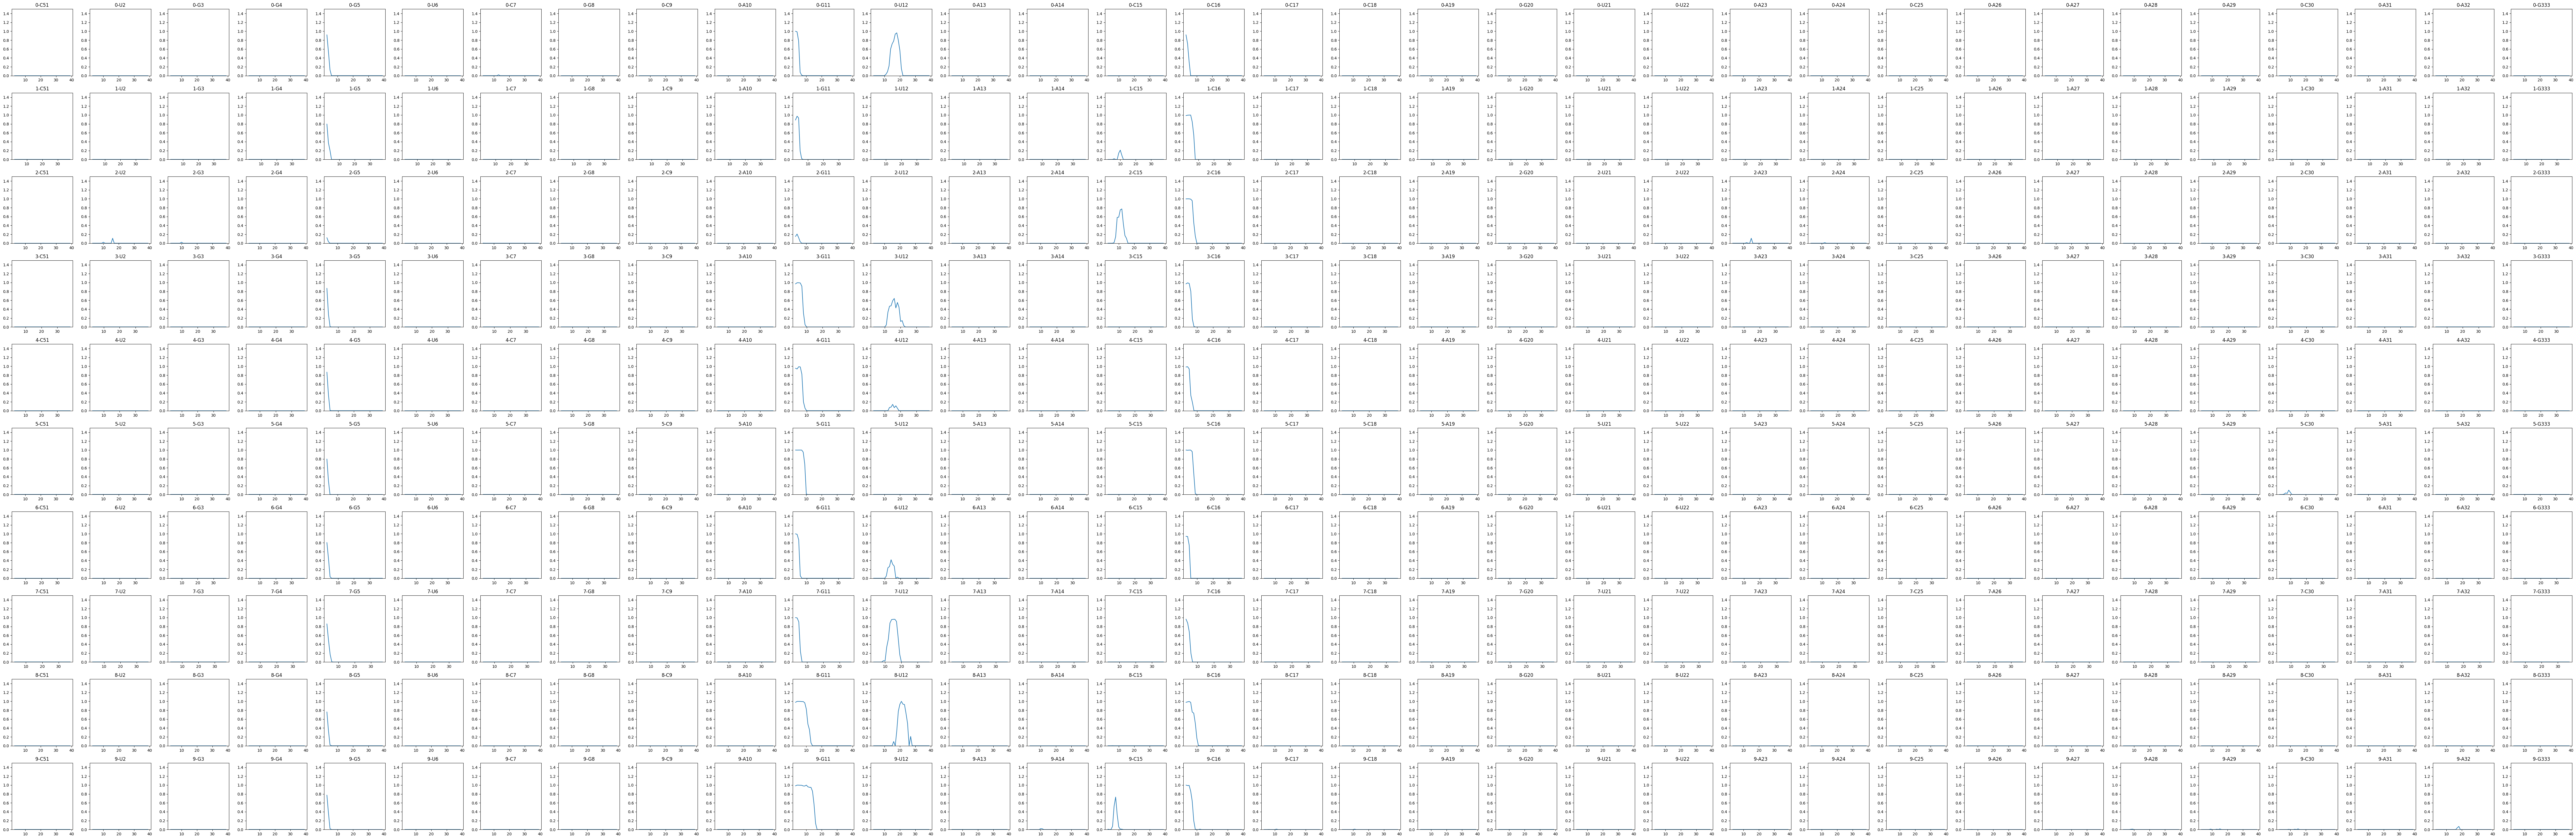

In [16]:
fig, ax = plt.subplots(len(pacs_interactions), 33)
fig.set_size_inches(92, 3*len(pacs_interactions))

for trial in range(len(pacs_interactions)):
    for residue_index_rna in range(0, 33):
        atom_idices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")

        pacs_interactions_rna_sum = pacs_interactions[trial, :, atom_idices_rna_residue].sum(axis=0)

        ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand-atom_index_ligand_min].sum(axis=0))
        #ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand_rgion["rrm"]-atom_index_ligand_min].sum(axis=0))
        #ax[trial, residue_index_rna].plot(pacs_interactions_rna_sum[atom_indices_ligand_rgion["rgg"]-atom_index_ligand_min].sum(axis=0))

        ax[trial, residue_index_rna].set_title(f"{trial}-{gleap_target.topology.residue(residue_index_rna)}")
        ax[trial, residue_index_rna].set_ylim(0, 1.5)

fig.tight_layout()
fig.savefig("./figures/pi_stacking2.png", dpi=300, bbox_inches="tight")

(18, 1062, 120) (29,) (18, 120) (120,)
(18, 1062, 120) (30,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (30,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (30,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (34,) (18, 120) (120,)
(18, 1062, 120) (30,) (18, 120) (120,)
(18, 1062, 120) (30,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (33,) (18, 120) (120,)
(18, 1062, 120) (31,) (18, 120) (120,)
(18, 1062, 120) (33,) (18

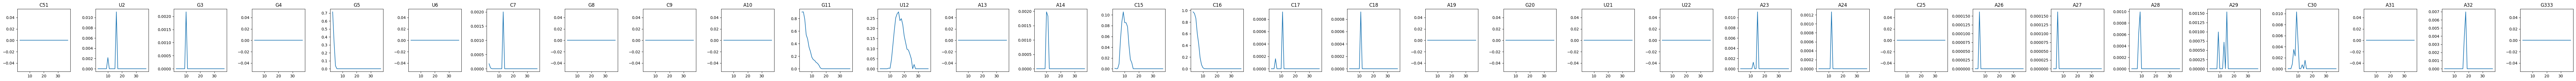

In [17]:



fig, ax = plt.subplots(1, 33)
fig.set_size_inches(92, 3)

pacs_interactions_trial_mean = pacs_interactions.mean(axis=0)

for residue_index_rna in range(0, 33):
    atom_idices_rna_residue = gleap_target.topology.select(f"resid {residue_index_rna}")

    pacs_interactions_trial_mean_rna_sum = pacs_interactions_trial_mean[:, atom_idices_rna_residue].sum(axis=1)

    print(pacs_interactions_trial_mean.shape, atom_idices_rna_residue.shape, pacs_interactions_trial_mean_rna_sum.shape, pacs_interactions_trial_mean_rna_sum.sum(axis=0).shape)

    ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum.sum(axis=0))
    #ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum[atom_indices_ligand_rgion["rrm"]-atom_index_ligand_min].sum(axis=0))
    #ax[residue_index_rna].plot(pacs_interactions_trial_mean_rna_sum[atom_indices_ligand_rgion["rgg"]-atom_index_ligand_min].sum(axis=0))

    ax[residue_index_rna].set_title(gleap_target.topology.residue(residue_index_rna))
    #ax[residue_index_rna].set_ylim(0, 1.5)

fig.tight_layout()
fig.savefig("./figures/pi_stacking3.png", dpi=300, bbox_inches="tight")